# Assignment 3 - Gaussian processes regression (for creating magnetic field maps)

- **Topic:** Understanding regression with Gaussian processes

- **Assessment:** The assignment will go through a pass/fail check.

- **Deadline:**  20-03-2025, 17:00
- **Submitting: SUBMIT ONLY `assignment3_groupNumber.ipynb` TO BRIGHTSPACE**. 
where groupNumber is your groupnumber


## Instructions
**Installation:** 
Use the `venvPSF` python kernel to ensure the python script runs as intended.

You may not use other packages for algorithm-related calculations.
You only need to complete (and submit) this file.
Please do not change the additional files `GP.py`, `helper.py` and `linAlg.py` and the dictionary `modelParameters` as this might result in breaking the assignment.



## AI Related Policy
We strongly discourage you to use AI tools for implementation assistance. It is your understanding of the problem that is tested in the final exam.


## Information
Please fill in your group number, names and student numbers in the cell below.



In [1]:
''' YOUR ANSWER HERE '''
groupNumber = 22

STUDENT_1_NAME = "Santiago Terreno Duarte"
STUDENT_1_STUDENT_NUMBER = "6144683"

STUDENT_2_NAME = "Pragun Srivastava"
STUDENT_2_STUDENT_NUMBER = "5542707"

# raise NotImplementedError()


''' DO NOT CHANGE THE CODE BELOW '''
import numpy as np
import matplotlib.pyplot as plt
import GP as GP
import helper as helper
import linAlg as linAlg
import scipy.optimize as opt

np.random.seed(groupNumber)

## Objectives

#### Goal

The final goal of this assignment is to create a map of the magnetic field, similar to the one used in the previous two assignments. In order to achieve this, you will first come to understand the basics of Gaussian process (GP) regression. In this assignment, you may assume that all the positions $ \mathbf{x}_k $ of an agent, for $k = {1, ..., K}$ time-steps, are known. In other words, the dynamic model and the initial position from the previous assignments are known exactly. Instead, you will learn a GP model $f(\cdot)$ to model the magnetic field using the non-linear measurement model:
$$ y_k = f(\mathbf{x}_k) + \epsilon_k $$

Where:
- $f(\cdot) \sim \mathcal{GP}(0, \kappa(\mathbf{x}, \mathbf{x}'))$ 

- $\kappa(\mathbf{x}, \mathbf{x}')$ is a kernel function, which takes two positions as inputs, and outputs a scalar.

- $y_k$ is a scalar measurement of the magnetic field at time-step $k$.

- $f(\cdot)$ is the reduced rank Gaussian process function.

- $\epsilon_k \sim \mathcal{N}(0, \sigma^2_{\epsilon})$ is Gaussian white noise.

- $\sigma^2_{\epsilon} \in \mathbb{R}^{1 \times 1} $ is the covariance of the measurement noise.


#### First create the squared exponential kernel
Maybe the most common choice for kernels in GP regression is the squared exponential kernel. The kernel is defined as
$$ \kappa_{\text{se}}(\mathbf{x}, \mathbf{x}') = \sigma^2_{\text{f}} \text{exp} \left(\frac{||\mathbf{x}-\mathbf{x}'||^2}{-2 \ell^2} \right),$$
where we have an arbitrary vector $\mathbf{x} \in \mathbb{R}^\text{D}$, with $D$ any positive integer. We have also introduced two new variables

- The length-scale $\ell$

- The signal amplitude $\sigma^2_{\text{f}}$

#### Task:

Based on the given definition of the squared exponential kernel, fill in the function `kernelSE` below. 


#### Analysis:

Elaborate on the following:

- What does a high or low kernel value represent?

- What changes when you change the value of the length-scale and the signal amplitude?  


## Answer

- The kernel encodes the properties of the function, and acts as the covariance between f(x) and f(x'). A low value would mean low correlation between the values, and therefore the resulting functions will vary more and be less smooth. Conversely, a high value would mean a high correaltion, with smoother functions.

- Length scale controls how quickly the correlation decays with distance, or in other words how quickly the function can vary. With a large lengthscale, more distant points remain correlated, resulting in smooth, slowly moving functions. With a small lengthscale, the correlation drops faster, so functions vary more over short distances. The signal amplitude scales the magnitude of the kernel. It controls the how far from zero the GP's outputs are expected to deviate. Large signal amplitude means large amplitude. Small signal amplitude means smaller amplitude, closer to the mean.


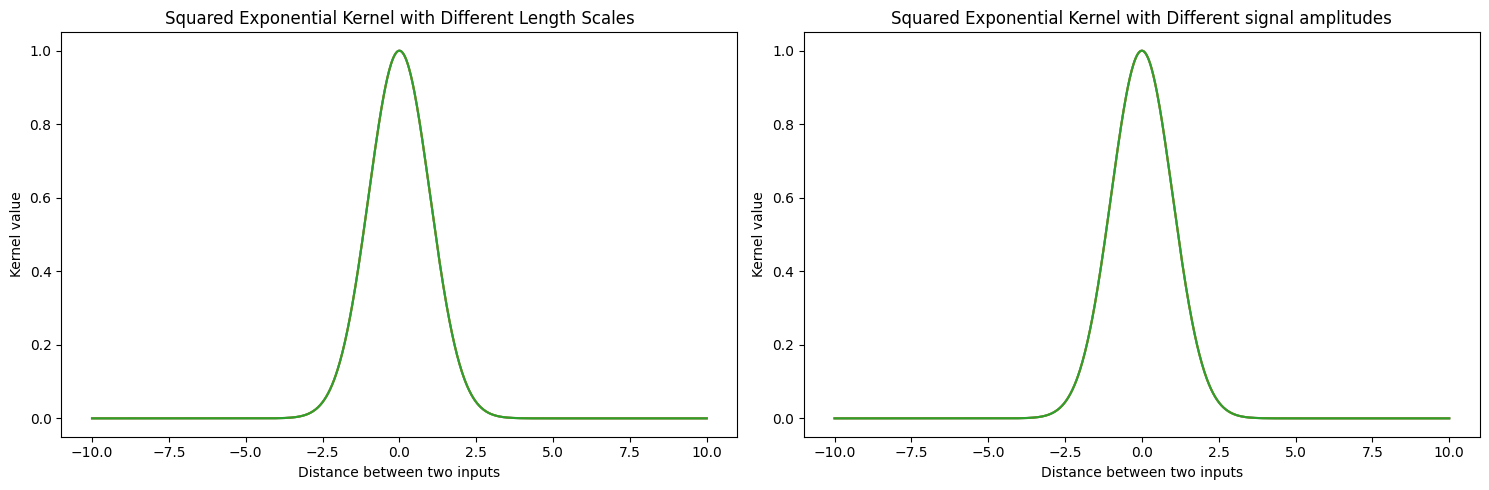

In [2]:
def kernelSE(x1, x2, lengthScaleSE, signalAmplitudeSE):
    helper.testKernelValue(x1, x2)
    """
    Compute the Squared Exponential Kernel for a for a single input pair {x1, x2}, 
    
    Args:
        x1: Array of shape (numDim, 1)
        x2: Array of shape (numDim, 1)
    Returns:
        K: Scalar kernel value of shape (1, 1)

    Hint: np.squeeze() returns a scalar if the array has only one element, otherwise it returns the array itself.
    """
    
    norm = (x1 - x2).T @ (x1 - x2)
    k = signalAmplitudeSE * np.exp(-0.5 * norm / (lengthScaleSE**2))
    
    return k.squeeze()


lengthScalesArray = np.array([1, 1, 1])
signalAmplitudesArray = np.array([1, 1, 1])




''' Code for plotting: Do not change code below '''
numDataPoints = 1000
x0 = np.zeros((1, 1))
xPred = np.linspace(-10, 10, numDataPoints).reshape(1, -1)
kernelValues = np.zeros((numDataPoints, len(lengthScalesArray) + len(signalAmplitudesArray)))
fig, axs = plt.subplots(1, 2, figsize=(15, 5))


for jndx, lengthScaleSE in enumerate(lengthScalesArray):
    for indx in range(numDataPoints):
        kernelValues[indx, jndx] = kernelSE(x0, xPred[:, indx], lengthScaleSE, signalAmplitudesArray[len(signalAmplitudesArray)//2])
    axs[0].plot(xPred[0, :], kernelValues[:, jndx])

for jndx, signalAmplitudeSE in enumerate(signalAmplitudesArray):
    for indx in range(numDataPoints):
        kernelValues[indx, jndx + len(lengthScalesArray)] = kernelSE(x0, xPred[:, indx], lengthScalesArray[len(lengthScalesArray)//2], signalAmplitudeSE)
    axs[1].plot(xPred[0, :], kernelValues[:, jndx + len(lengthScalesArray)])

axs[0].set_title("Squared Exponential Kernel with Different Length Scales")
axs[0].set_xlabel("Distance between two inputs")
axs[0].set_ylabel("Kernel value")
axs[1].set_title("Squared Exponential Kernel with Different signal amplitudes")
axs[1].set_xlabel("Distance between two inputs")
axs[1].set_ylabel("Kernel value")

plt.tight_layout()
plt.show()



#### Sampling from a Gaussian process prior
Sampling from a Gaussian process can be useful, for e.g. creating artificial datasets. Let us continue with the squared exponential kernel (although this extends to all valid kernels). Using this kernel, we can make a kernel matrix as

$$
\mathbf{K}_{\text{se}}(\mathbf{X}_{1:K}, \mathbf{X}_{1:K}) = 
\begin{bmatrix} \kappa_{\text{se}}(\mathbf{x}_{1}, \mathbf{x}_{\text{1}})  & \dots & \kappa_{\text{se}}(\mathbf{x}_{1}, \mathbf{x}_{K}) \\
\vdots & \ddots & \vdots \\
\kappa_{\text{se}}(\mathbf{x}_{K}, \mathbf{x}_{1}) & \dots & \kappa_{\text{se}}(\mathbf{x}_{K}, \mathbf{x}_{K})
\end{bmatrix}
$$

The prior covariance kernel for all prediction locations $\mathbf{X}_{\star}$ then becomes

$$
\begin{aligned}
\mathbf{f}_{\star} &\sim \mathcal{N}\left(0, \mathbf{K}(\mathbf{X}_{\star},\mathbf{X}_{\star})\right), \\
&\sim \mathcal{N}\left(0, \mathbf{L} \mathbf{L}^{\mathsf{T}}\right) 
\end{aligned}
$$

Where $\mathbf{L}$ denotes the (lower triangular) cholesky decomposition

$$
\mathbf{f}_{\star} = \mathbf{L}\mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}\left(0, \mathbf{I} \right)  \\
$$

For more details see e.g. (https://gaussianprocess.org/gpml/)

#### Task:

Using the Cholesky decomposition, fill in the function `samplingFromPrior`, such that you can sample `numSamples` function evaluations from a GP prior with the squared exponential kernel.



#### Analysis:

Elaborate on what happens in the plot when you change the values of the two parameters

- lengthScaleSE
- signalAmplitudeSE


## Answer

- lengthScaleSE: The length scale indicates how smooth the functions will be. The larger the length scale, the smoother the function. Therefore, if the lengthscale is too large the functions become almost straight lines (due to high correlation between different points), and if it is too low they have very high variation, resembling noise (very low correlation between points).

- signalAmplitudeSE: Signal amplitude scales the vertical range of the sampled functions. Increasing this parameter produces samples with larger deviations from zero, i.e. taller peaks and deeper troughs. Inversely, decreasing the signal amplitude results in smaller deviations.


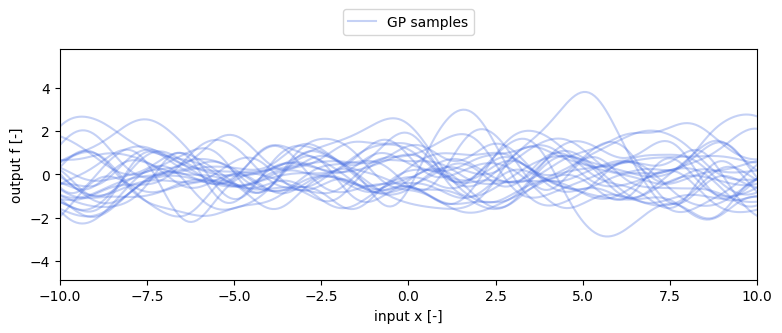

In [3]:

def kernelMatrixSE(x1, x2, lengthScaleSE, signalAmplitudeSE):
    helper.testKernelMatrix(x1, x2)
    """
    Compute the Squared Exponential Kernel Matrix for a set of input pairs, 
    you already used kernelSE to compute the kernel value for a single input pair.
    
    Args:
        x1: Array of shape (numDim, numInputs1)
        x2: Array of shape (numDim, numInputs2)
    Returns:
        K: Kernel matrix of shape (numInputs1, numInputs2)

    Hint: use could make use of numDim, numInputs = x.shape[0], x.shape[1] to find the dimensions
    """

    n = x1.shape[1]
    m = x2.shape[1]
    
    K = np.zeros([n, m])

    for i in range(n):
        for j in range(m):

            K[i][j] = kernelSE(x1[:,i:i+1], x2[:,j:j+1], lengthScaleSE, signalAmplitudeSE)
    
    return K

def samplingFromPrior(xPrior, lengthScaleSE, signalAmplitudeSE):
    """
    Sample a function from the Gaussian Process Prior defined by the Squared Exponential Kernel.

    Args:
        xPrior: Array of shape (numDim, numInputs) containing the input locations at which to sample the function.
        lengthScaleSE: Length scale hyperparameter for the Squared Exponential Kernel.
        signalAmplitudeSE: signal amplitude hyperparameter for the Squared Exponential Kernel.
    Returns:
        fPrior: Array of shape (numInputs, 1) containing the sampled function values
    
    
    Hint: You already used kernelMatrixSE to compute the kernel matrix for a set of input pairs, 
    You can use the Cholesky decomposition to sample from the multivariate Gaussian distribution defined by the kernel matrix.
    """

    K = kernelMatrixSE(xPrior, xPrior, lengthScaleSE, signalAmplitudeSE)
    K = K + 1e-8 * np.eye(K.shape[0]) # To avoid numerical issues with cholesky decomposition (since the zeros can be slightly negative and therefore th ematrix won't be positive definite)

    L = np.linalg.cholesky(K, upper=False)

    num_inputs = xPrior.shape[1]
    # z = np.random.multivariate_normal(mean = np.zeros(num_inputs), cov = np.eye(num_inputs), size=None).reshape([num_inputs,1])
    z = np.random.normal(0, 1, size=(num_inputs, 1))

    fPrior = L @ z
    
    return fPrior.reshape(-1, 1)



lengthScaleSE = 1
signalAmplitudeSE = 1



''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-10, 10, 5).reshape(1, -1)
xPred = np.linspace(-10, 10, 250).reshape(1, -1)

numSamples = 25
fPriorSamples = np.zeros((numSamples, 250))
fPosteriorSamples = np.zeros((numSamples, 250))
for samplendx in range(numSamples):
    fPriorSamples[samplendx, :] = samplingFromPrior(xPred, lengthScaleSE, signalAmplitudeSE).ravel()

helper.makeGaussianProcessSamplingPlots(xPred, fPriorSamples)


#### Gaussian process predictions

Previously, we considered the case where our data has no measurement noise. Below we show the derivation for the case when we have noisy data, which leads to joint distribution

$$
\begin{bmatrix}
\mathbf{y}_{1:\text{K}} \\
\mathbf{f}_{\star}
\end{bmatrix}
\sim \mathcal{N}\left(
\mathbf{0},
\begin{bmatrix}
\mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) + \sigma^2_{\epsilon} \mathbf{I}_{K} & \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{x}_{\star}) \\
\mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) & \mathbf{K}(\mathbf{x}_{\star}, \mathbf{x}_{\star})
\end{bmatrix}
\right)
$$

The joint distribution leads to the predictive mean and covariance as

$$
\begin{aligned} \mathbb{E}[f(\mathbf{x}_{\star})] &= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) \left(\mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) +  \sigma^2_{\epsilon} \mathbf{I}_{K} \right)^{-1}\mathbf{y}_{1:\text{K}}, \\
\mathbb{V}[f(\mathbf{x}_{\star})] &= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) \left(\mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) +  \sigma^2_{\epsilon} \mathbf{I}_{K} \right)^{-1} \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{x}_{\star}) 
\end{aligned}$$

However, in practice, the inversion can be numerically unstable, to improve stability we use the Cholesky decomposition from \cite{}: 

$$ 
\begin{aligned} \mathbf{L} &:= \text{chol}\left( \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) +  \sigma^2_{\epsilon} \mathbf{I}_{K} \right), \\
\mathbf{a} &:= (\mathbf{L}^{\mathsf{T}})^{-1} \left(\mathbf{L}^{-1} \mathbf{y}_{1:\text{K}} \right), \\
\mathbf{v} &:= \mathbf{L}^{-1} \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{x}_{\star}), \\
\mathbb{E}[f(\mathbf{x}_{\star})] &:= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) \mathbf{a}, \\
\mathbb{V}[f(\mathbf{x}_{\star})] &:= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{x}_{\star}) - \mathbf{v}^{\mathsf{T}} \mathbf{v}  
\end{aligned}$$

#### Task:

- Finish the implementation of `predictSE`, such that you can predict the mean and covariance of the posterior GP, at given test locations $\mathbf{X}_{\star}$.

- By hand, tune the hyper-parameters `lengthScaleSquared`, `signalAmplitudeSE` `noiseVariance`, to make predictions on the give dataset.

#### Analysis:

Elaborate on the quality of the prediction on the left half of the figure and the right half of the figure. 
- How well does it predict the latent function?

## Answer

1. Elaborate on the quality of the prediction on the left half of the figure and the right half of the figure

In the left half, the prediction quality is good because training data is available here. The mean prediction closely tracks the latent function, and the 2 standard deviation band is narrow. This indicates low uncertainty. The GP samples are closer to the mean.

In the right half, the prediction quality is significantly worse. There are no training points in this region, so the GP has no information to condition itself on. The mean reverts to the prior mean (which is 0), missing the sinusoidal pattern. The GP samples are also more spread out in this case, and no longer follow the latent function.<br>

The covariance is also notably smaller near the points where there is data, and as we move away from that region towards the right, the covariance falls back to the prior covariance (which is the maximum value it can achieve).<br>

2. How well does it predict the latent function

When the data is present (left half) the GP recovers the sine wave well. The mean is close to the true function and the uncertainty is small. When the data is not present (right half), the GP cannot infer the periodic pattern. This indicates a limitation of the squared exponential kernel. Since this kernel encodes only smoothness, and not periodicity, it has no way to know/predict that the function is periodic. A periodic kernel would thus be more effective at extrapolating in this case.


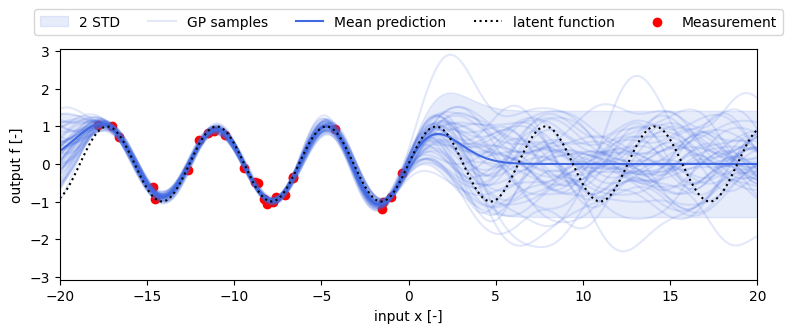

In [4]:
def predictSE(xStar, xData, yData, lengthScaleSE, signalAmplitudeSE, noiseVariance):
    """
    Compute the mean and covariance of the Gaussian Process Posterior defined by the Squared Exponential Kernel

    Args:
        xStar: Array of shape (numDim, numTestInputs) containing the input locations
        xData: Array of shape (numDim, numTrainInputs) containing the training input locations
        yData: Array of shape (numTrainInputs, 1) containing the training output values
        lengthScaleSE: Length-scale hyperparameter for the Squared Exponential Kernel.
        signalAmplitudeSE: signal amplitude hyperparameter for the Squared Exponential Kernel.
        noiseVariance: Noise variance hyperparameter for the Gaussian Process.
    Returns:
        mean: Array of shape (numTestInputs, 1) containing the mean of the Gaussian Process Posterior at the test input locations
        cov: Array of shape (numTestInputs, numTestInputs) containing the covariance of the Gaussian Process Posterior at the test input locations
    """

    numTrainInputs = xData.shape[1]
    
    K1 = kernelMatrixSE(xData, xData, lengthScaleSE, signalAmplitudeSE)
    K2 = kernelMatrixSE(xData, xStar, lengthScaleSE, signalAmplitudeSE)
    K3 = kernelMatrixSE(xStar, xData, lengthScaleSE, signalAmplitudeSE)
    K4 = kernelMatrixSE(xStar, xStar, lengthScaleSE, signalAmplitudeSE)

    L = np.linalg.cholesky(K1 + noiseVariance * np.eye(numTrainInputs), upper=False)

    L_inv = np.linalg.inv(L)
    a = L_inv.T @ (L_inv @ yData)
    v = L_inv @ K2

    mean = K3 @ a
    cov = K4 - v.T @ v
    
    return mean, cov



lengthScaleSE = 2
signalAmplitudeSE = .5
noiseVariance = 0.01


''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-20, 0, 25).reshape(1, -1)
xPred = np.linspace(-20, 20, 250).reshape(1, -1)
yData1D = helper.generateData(xData, 'sin')


f, cov = predictSE(xPred, xData, yData1D, lengthScaleSE, signalAmplitudeSE, noiseVariance)
helper.makeGaussianProcessPredictionPlots(xData, yData1D, xPred, f, cov, 'sin')

#### Sampling from a Gaussian Process Posterior

As we are usually not interested in the prior, we want to incorporate data. Let's consider some noise-free data, we can then make a joint distribution over both the training and test points:



$$
\begin{bmatrix}
\mathbf{f}_{1:\text{K}} \\
\mathbf{f}_{\star}
\end{bmatrix}
\sim \mathcal{N}\left(
\mathbf{0},
\begin{bmatrix}
\mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) & \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{x}_{\star}) \\
\mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) & \mathbf{K}(\mathbf{x}_{\star}, \mathbf{x}_{\star})
\end{bmatrix}
\right)
$$

This allows us to compute the posterior distribution of a Gaussian Process (GP). Below are the posterior mean $ \mathbf{\mu}_{\star} $ and posterior covariance $ \mathbf{\Sigma}_{\star} $


$$
\begin{aligned} 
\mathbf{\mu}_{\star} &= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}})^{-1} \mathbf{f}_{1:\text{K}}, \\
\mathbf{\Sigma}_{\star} &= \mathbf{K}(\mathbf{x}_{\star}, \mathbf{x}_{\star}) - \mathbf{K}(\mathbf{x}_{\star}, \mathbf{X}_{1:\text{K}}) \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}})^{-1} \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{x}_{\star})
\end{aligned}
$$

Again, using $\mathbf{L} \mathbf{L}^{K} = \left(\mathbf{\Sigma}_{\star} \right)$ we can write

$$
\mathbf{f}_{\star} = \mu_{\star} + \mathbf{L}\mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}\left(0, \mathbf{I} \right)  \\
$$

#### Task:

Fill in the function `samplingFromPosterior`, such that you can sample `Nsamples` function evaluations from a GP prior with the squared exponential kernel.

#### Analysis:

Elaborate on what happens in the plot when you change the values of the two parameters

- lengthScaleSE
- signalAmplitudeSE


## Answer

- lengthScaleSE: As the lengthscale is increased, the measurement points become more aligned and the posterior GP samples are closer to each other. The measurements are obtained from a sample of the prior, and as mentioned previously as the lengthscale increases the prior functions approximate more and more to straight lines, so it makes total sense that the measurement points become more aligned since they come from one realization of the prior. The posterior GP samples are also smoother when the lengthscale increases, so they also tend to become a straight line in the limit. Furthermore, since the absence of measurement noise forces the sampled functions to go through the points, the mentioned factors generate that, as the lengthscale is increased, the GP samples tend to all become exactly the same line going through the aligned measurement points. Conversely, as we decrease the lengthsale, the GP samples vary more in all points outside the measurements, and they tend to diverge from each other more even in the vicinity of the measurement points, allowing the functions to change more quickly. As we keep decreasing the lengthscale, the GP samples start to resemble noise, and it is barely visible that they all go through the measurement points since they quickly diverge to different unrelated values immediately after and before.

- signalAmplitudeSE: The signal amplitude, as before, controls the vertical scale of the posterior samples. Increasing the signal amplitude allows the samples to deviate further from zero in regions without data, resulting in wider uncertainty bands, especially away from observations. Meanwhile, decreasing the signal amplitude constrains the samples closer to 0 in regions with less data. Near the measurements the samples perfectly match the observed values, so the effect of the signal amplitude is most pronounced between data points as well as the edges (where there is no observed data). signalAmplitudeSE does not affect the overall shape of the functions because the same amplitude affects both the prior from where the measurements come as well as the posterior functions. Instead, its main task is to scale the vertical range of the functions.

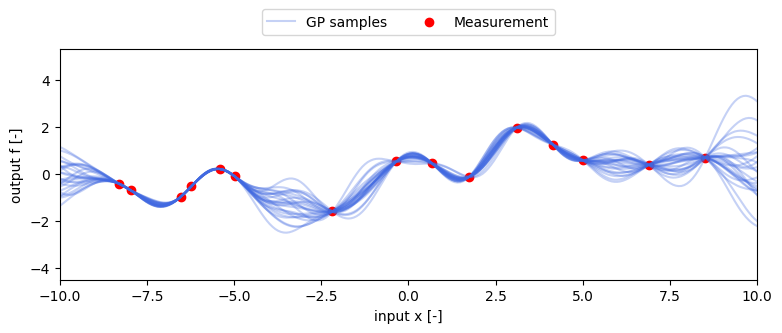

In [5]:

def samplingFromPosterior(xPosterior, xPrior, fprior, lengthScaleSE, signalAmplitudeSE):
    """
    Sample from the posterior distribution of a Gaussian Process.

    Args:
        xPosterior: Array of shape (numDim, numTestInputs) containing the test input locations
        xPrior: Array of shape (numDim, numTrainInputs) containing the training input locations
        fprior: Array of shape (numTrainInputs, 1) containing the training output values
        lengthScaleSE: Length-scale hyperparameter for the Squared Exponential Kernel.
        signalAmplitudeSE: signal amplitude hyperparameter for the Squared Exponential Kernel.
    Returns:
        samples: Array of shape (numTestInputs,) containing samples from the posterior distribution
    """

    numTrainInputs = xPrior.shape[1]
    numTestInputs = xPosterior.shape[1]
    
    K1 = kernelMatrixSE(xPrior, xPrior, lengthScaleSE, signalAmplitudeSE)
    K2 = kernelMatrixSE(xPrior, xPosterior, lengthScaleSE, signalAmplitudeSE)
    K3 = kernelMatrixSE(xPosterior, xPrior, lengthScaleSE, signalAmplitudeSE)
    K4 = kernelMatrixSE(xPosterior, xPosterior, lengthScaleSE, signalAmplitudeSE)

    K1 = K1 + 1e-6 * np.eye(numTrainInputs) 
    K1_inv = np.linalg.inv(K1)
    
    mu = K3 @ K1_inv @ fprior

    cov = K4 - K3 @ K1_inv @ K2
    cov = cov + 1e-6 * np.eye(numTestInputs)

    L = np.linalg.cholesky(cov, upper=False)
    z = np.random.normal(0, 1, size=(numTestInputs, 1))
    
    samples = mu + L @ z
    
    return samples.flatten()



lengthScaleSE = 1
signalAmplitudeSE = 1

''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-10, 10, 15).reshape(1, -1)
fData = samplingFromPrior(xData, lengthScaleSE, signalAmplitudeSE)

xPred = np.linspace(-10, 10, 250).reshape(1, -1)
numSamples = 25
fPriorSamples = np.zeros((numSamples, 250))
for samplendx in range(numSamples):
    fPosteriorSamples[samplendx, :] = samplingFromPosterior(xPred, xData, fData, lengthScaleSE, signalAmplitudeSE).ravel()

helper.makeGaussianProcessSamplingPlots(xPred, fPosteriorSamples, xData, fData)


#### Periodic kernel

There are many kernels to choose from and it is up to the engineer to choose the right kernel for the right task. A list of different kernels can be found in the kernel cookbook (https://www.cs.toronto.edu/~duvenaud/cookbook/). A better suited kernel for the previously given data might be a periodic kernel, which can be described with
$$\kappa_{\text{per}}(\mathbf{x},\mathbf{x}') = \sigma^2_{\text{per}}  \text{exp} \left( \frac{\text{sin} \left( \pi \frac{|\mathbf{x} - \mathbf{x}'|}{\text{period}} \right)^2 }{-0.5 l^2} \right)$$


#### Task:

- Given the periodic kernel above, finish the implementation of the functions `kernelPeriodic`, `kernelMatrixPeriodic` and `predictPeriodic`.

- Manually tune the hyper-parameters `lengthScaleSquared`, `signalAmplitudePeriodic`, `noiseVariance`, and  `period`.


#### Analysis:

Elaborate on the quality of the prediction on the left half of the figure and the right half of the figure.
- How well does it predict the latent function? 
- How does it compare to the prediction of the SE kernel

## Answer

- This kernel leads to a very good prediction of the latent function. The mean prediction closely follows the latent function and the confidence band is narrow. When measurements are not present (right half), the advantages of the periodic kernel are instantly recognizable. Since the periodic kernel can encode periodicity, the oscillatory behaviour can be represented very well, and the GP can extrapolate the sinusoidal pattern into the right half. Intrinsically the functions are encoded to be periodic, and therefore with very few data points the latent sinusoid can be predicted extremely well for all values, even if they are far from the measurements.

- This kernel performs much better than the SE kernel. The SE kernel was only suitable for interpolation in regions where measurements are available, but failed at extrapolation (i.e. it failed to make accurate predictions on the right half where measurements are not available). As a result, in the right half, the SE kernel quickly reverted to the prior values of mean and covariance. Now with the periodic kernel, the periodicity of the data is taken into account, allowing successful extrapolation far away from the measurements, even with only a few data points. This shows the significance of choosing a suitable kernel that matches the prior knowledge about the data.

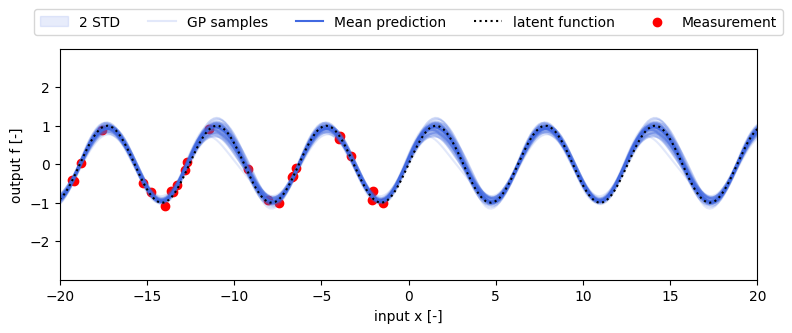

In [6]:
def kernelPeriodic(x1, x2, lengthScalePeriodic, signalAmplitudePeriodic, period):
    helper.testKernelValue(x1, x2)
    """
    Compute the Periodic Kernel for a for a single input pair {x1, x2},

    Args:
        x1: Array of shape (numDim, 1)
        x2: Array of shape (numDim, 1)
        lengthScalePeriodic: Length scale hyperparameter for the Periodic Kernel.
        signalAmplitudePeriodic: signal amplitude hyperparameter for the Periodic Kernel.
        period: Period hyperparameter for the Periodic Kernel.
    Returns:
        K: Scalar kernel value of shape (1, 1)
    """ 

    sin_term = (np.pi * np.linalg.norm(x1 - x2, ord=2)) / period
    exp_term = -2 * ( (np.sin(sin_term)/lengthScalePeriodic)**2 )
    
    k = signalAmplitudePeriodic * np.exp(exp_term)
    
    return k

def kernelMatrixPeriodic(x1, x2, lengthScalePeriodic, signalAmplitudePeriodic, period):
    helper.testKernelMatrix(x1, x2)
    """
    Compute the Periodic Kernel matrix for a set of input pairs {x1, x2}.

    Args:
        x1: Array of shape (numDim, numInputs1)
        x2: Array of shape (numDim, numInputs2)
        lengthScalePeriodic: Length scale hyperparameter for the Periodic Kernel.
        signalAmplitudePeriodic: signal amplitude hyperparameter for the Periodic Kernel.
        period: Period hyperparameter for the Periodic Kernel.
    Returns:
        K: Kernel matrix of shape (numInputs1, numInputs2)
    """
    n = x1.shape[1]
    m = x2.shape[1]
    
    K = np.zeros([n, m])

    for i in range(n):
        for j in range(m):

            K[i][j] = kernelPeriodic(x1[:,i:i+1], x2[:,j:j+1], lengthScalePeriodic, signalAmplitudePeriodic, period)
            
    return K

def predictPeriodic(xStar, xData, yData, lengthScalePeriodic, signalAmplitudePeriodic, period, noiseVariance):
    """
    Compute the mean and covariance of the Gaussian Process Posterior defined by the Periodic Kernel

    Args:
        xStar: Array of shape (numDim, numTestInputs) containing the input locations
        xData: Array of shape (numDim, numTrainInputs) containing the training input locations
        yData: Array of shape (numTrainInputs, 1) containing the training output values
        lengthScalePeriodic: Length scale hyperparameter for the Periodic Kernel.
        signalAmplitudePeriodic: signal amplitude hyperparameter for the Periodic Kernel.
        period: Period hyperparameter for the Periodic Kernel.
        noiseVariance: Noise variance hyperparameter for the Gaussian Process.
    Returns:
        mean: Array of shape (numTestInputs, 1) containing the mean of the Gaussian Process Posterior at the test input locations
        cov: Array of shape (numTestInputs, numTestInputs) containing the covariance of the Gaussian Process Posterior at the test input locations
    """
    
    numTrainInputs = xData.shape[1]
    
    K1 = kernelMatrixPeriodic(xData, xData, lengthScalePeriodic, signalAmplitudePeriodic, period)
    K2 = kernelMatrixPeriodic(xData, xStar, lengthScalePeriodic, signalAmplitudePeriodic, period)
    K3 = kernelMatrixPeriodic(xStar, xData, lengthScalePeriodic, signalAmplitudePeriodic, period)
    K4 = kernelMatrixPeriodic(xStar, xStar, lengthScalePeriodic, signalAmplitudePeriodic, period)

    L = np.linalg.cholesky(K1 + noiseVariance * np.eye(numTrainInputs), upper=False)

    L_inv = np.linalg.inv(L)
    a = L_inv.T @ (L_inv @ yData)
    v = L_inv @ K2

    mean = K3 @ a
    cov = K4 - v.T @ v
    
    return mean, cov



lengthScalePeriodic = 1
signalAmplitudePeriodic = .5
noiseVariance = 0.01
period = 4*np.pi

''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-20, 0, 25).reshape(1, -1)
xPred = np.linspace(-20, 20, 250).reshape(1, -1)
yData1D = helper.generateData(xData, 'sin')

f, cov = predictPeriodic(xPred, xData, yData1D, lengthScalePeriodic, signalAmplitudePeriodic, period, noiseVariance)
helper.makeGaussianProcessPredictionPlots(xData, yData1D, xPred, f, cov, 'sin')

#### Linear + periodic kernel

Assume the observed data has a linear ascending trend. Using only periodic kernel will fail the prediction as shown below:

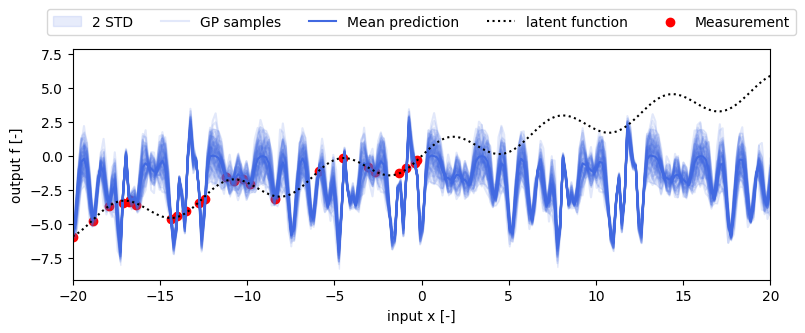

In [7]:
lengthScalePeriodic = .1
signalAmplitudePeriodic = 1
noiseVariance = 0.01
period = 4*np.pi


''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-20, 0, 25).reshape(1, -1)
xPred = np.linspace(-20, 20, 250).reshape(1, -1)
yData1D_v2 = helper.generateData(xData, 'linsin', addNoise = True)
f, cov = predictPeriodic(xPred, xData, yData1D_v2, lengthScalePeriodic, signalAmplitudePeriodic, period, noiseVariance)
helper.makeGaussianProcessPredictionPlots(xData, yData1D_v2, xPred, f, cov, 'linsin')


In this case, it is also possible to combine kernels, for now we will stick with addition (for all mathematical properties see the kernel cookbook https://www.cs.toronto.edu/~duvenaud/cookbook/). In this example, we will add a periodic kernel and a linear kernel, the latter is defined as



$$
\kappa_{\text{lin}} = \sigma^2_{\text{lin}} \mathbf{x}^{\mathsf{T}} \mathbf{x}'
$$


#### Task:

- Given the periodic kernel above, finish the implementation of the funcitons `kernelLin`, `kernelMatrixLin` and `predictLinPeriodic`.

- Manually tune the hyper-parameters `lengthScalePeriodic`, `signalAmplitudePeriodic`, `noiseVariance`, `period` and `signalAmplitudeLin`.


#### Analysis:

Elaborate on the quality of the prediction on the left half of the figure and the right half of the figure.
- How well does it predict the latent function? 

## Answer

The prediction of the latent function is very good because the combined kernel is able to capture both components of the data: the oscillatory behavior and the linear upward trend. The periodic kernel models the sinusoidal pattern, while the linear kernel captures the overall increasing trend of the function. As a result, the Gaussian process can represent the structure of the latent function very well.<br>

The mean prediction closely follows the latent function, and the confidence band is narrow around the observations. Therefore, the prediction quality is strong across the whole range. This is because the kernel is able to fit the structure of the measurements, including both the periodic and linear aspects of the trend.<br>

These observations demonstrate the value of kernel composition. By combining a suitable combination of kernels, the behaviour of the data is matched more successfully.<br>

However, moving far into the right hand side, it can be seen that the functions start to become more separated and drift away from the mean, indicating that the uncertainty is increasing. In other words, if we move far away from the measurements, the predictions start to get worse. Nonetheless, the combined kernel still yields very good results, certainly much better than the periodic kernel on its own.

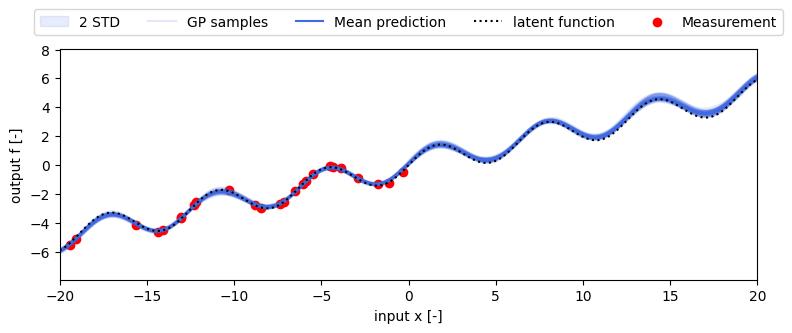

In [8]:
def kernelLinear(x1, x2, signalAmplitudeLinear):
    helper.testKernelValue(x1, x2)
    """
    Compute the Linear Kernel for a for a single input pair {x1, x2},

    Args:
        x1: Array of shape (numDim, 1)
        x2: Array of shape (numDim, 1)
        signalAmplitudeLinear: signal amplitude hyperparameter for the Linear Kernel.
    Returns:
        K: Scalar kernel value of shape (1, 1)
    """

    k = signalAmplitudeLinear * (x1.T @ x2)
    k = k.squeeze()
    
    return k

def kernelMatrixLinear(x1, x2, signalAmplitudeLinear):
    helper.testKernelMatrix(x1, x2)
    """
    Compute the Linear Kernel matrix for a set of input pairs {x1, x2}.

    Args:
        x1: Array of shape (numDim, numInputs1)
        x2: Array of shape (numDim, numInputs2)
        signalAmplitudeLinear: signal amplitude hyperparameter for the Linear Kernel.
    Returns:
        K: Kernel matrix of shape (numInputs1, numInputs2)

    """
    
    n = x1.shape[1]
    m = x2.shape[1]
    
    K = np.zeros([n, m])

    for i in range(n):
        for j in range(m):

            K[i][j] = kernelLinear(x1[:,i:i+1], x2[:,j:j+1], signalAmplitudeLinear)
            
    return K


def predictLinearPeriodic(xStar, xData, yData, lengthScalePeriodic, signalAmplitudePeriodic, period, signalAmplitudeLinear, noiseVariance):
    """ 
    Compute the mean and covariance of the Gaussian Process Posterior defined by the sum of a Periodic Kernel and a Linear Kernel
    Args:
        xStar: Array of shape (numDim, numTestInputs) containing the input locations
        xData: Array of shape (numDim, numTrainInputs) containing the training input locations
        yData: Array of shape (numTrainInputs, 1) containing the training output values
        lengthScalePeriodic: Length scale hyperparameter for the Periodic Kernel.
        signalAmplitudePeriodic: signal amplitude hyperparameter for the Periodic Kernel.
        period: Period hyperparameter for the Periodic Kernel.
        signalAmplitudeLinear: signal amplitude hyperparameter for the Linear Kernel.
        noiseVariance: Noise variance hyperparameter for the Gaussian Process.
    Returns:
        mean: Array of shape (numTestInputs, 1) containing the mean of the Gaussian Process Posterior at the test input locations
        cov: Array of shape (numTestInputs, numTestInputs) containing the covariance of the Gaussian Process Posterior at the test input locations

    """
    numTrainInputs = xData.shape[1]
    
    K1 = kernelMatrixPeriodic(xData, xData, lengthScalePeriodic, signalAmplitudePeriodic, period) + kernelMatrixLinear(xData, xData, signalAmplitudeLinear)
    K2 = kernelMatrixPeriodic(xData, xStar, lengthScalePeriodic, signalAmplitudePeriodic, period) + kernelMatrixLinear(xData, xStar, signalAmplitudeLinear)
    K3 = kernelMatrixPeriodic(xStar, xData, lengthScalePeriodic, signalAmplitudePeriodic, period) + kernelMatrixLinear(xStar, xData, signalAmplitudeLinear)
    K4 = kernelMatrixPeriodic(xStar, xStar, lengthScalePeriodic, signalAmplitudePeriodic, period) + kernelMatrixLinear(xStar, xStar, signalAmplitudeLinear)

    L = np.linalg.cholesky(K1 + noiseVariance * np.eye(numTrainInputs), upper=False)

    L_inv = np.linalg.inv(L)
    a = L_inv.T @ (L_inv @ yData)
    v = L_inv @ K2

    mean = K3 @ a
    cov = K4 - v.T @ v
    
    return mean, cov


lengthScalePeriodic = 1
signalAmplitudePeriodic = 0.1
noiseVariance = 0.01
period = 4*np.pi
signalAmplitudeLinear = 100

''' Code for plotting: Do not change code below '''
xData = np.random.uniform(-20, 0, 25).reshape(1, -1)
xPred = np.linspace(-20, 20, 250).reshape(1, -1)
yData1D_v2 = helper.generateData(xData, 'linsin', addNoise = True)
f, cov = predictLinearPeriodic(xPred, xData, yData1D_v2, lengthScalePeriodic, signalAmplitudePeriodic, period, signalAmplitudeLinear, noiseVariance)
helper.makeGaussianProcessPredictionPlots(xData, yData1D_v2, xPred, f, cov, 'linsin')


### Optimising the Log Marginal Likelihood

Instead of manually tuning the hyper-parameters, which will be extremely tedious for large data-sets, the hyper-parmaeters can be optimised. This can be done by maximising the marginal log-likelihood with respect to the set of hyper-parameters $\theta$:

$$
\theta_{\text{ML}} = \text{arg} \max_\theta \underbrace{\log p(y|x)}_{\mathcal{L}} 
$$

With

$$
\mathcal{L} = - \frac{1}{2} \operatorname{tr} (\mathbf{y}_{1:\text{K}}^\mathsf{T} \mathbf{K}_{\text{y}}  \mathbf{y}_{1:\text{K}}) - \frac{1}{2} \log |\mathbf{K}_{\text{y}} |  - \frac{T}{2} \log 2 \pi
$$

where 

$$
\mathbf{K}_{\text{y}} = \mathbf{K}(\mathbf{X}_{1:\text{K}}, \mathbf{X}_{1:\text{K}}) + \sigma^2_{\epsilon} \mathbf{I}_{T}
$$

Below, you are given the cost function and its gradient in the functions `GP.expLogML` and `GP.expGradLogML` respectively.

#### Task:
Initialise the hyper-parameters to orders of different magnitudes


#### Analysis:
- How can you find out whether the hyper parameter optimum is unique, or whether there maybe other local optima? 
- If there are local optima, find some, and explain what the model is doing in each case. Which fit is best, and why?


#### Note:
If you are interested in the under the hood functions: we re-paramaterise the hyper-parameters into the log space with $s = \text{log}(\theta)$ (not the log in the log marginal likelihood), which ensures non-negatives of the hyper-parameters and generally can be expected to have better perfomance when the initialisation of the hyper-parameters are far off.

## Answer

- We run the optimization trying very different initial values, and check whether the optimal result is the same or not. If there was only one optimum, the algorithm should reach it consistently independently of the initial values (leaving aside of course initial values that are so far off that a maximum number of iterations is reached too early). In this case, it is very clear that there are multiple local optima. For example, by tuning just the lengthscale, moving the initial values from (2, 1, 0.01) to (5, 1, 0.01), the final optimum values are similar to those of the initial condition in both cases. Moreover, there are certain initial values which even if left unchanged produce different optimum solutions in each run, for instance by using (2, 0.1, 0.1) in one run reaches (8.5, 0.17, 0.62) as optimal values, and in another reaches (1.5, 0.13, 0.14).

- In the previous point several local optima were found. The different local optima correspond to the values that fit the data best given the properties that the initial values pre-assign to the function. If for instance the initial lengthscale is high, producing an initial smooth solution, then the optimal value is unlikely to yield functions whose smoothness is very different, since there is a local minimum on the neighbourhood of those initial conditions that is not too far from them. Some solutions produce a GP that is too smooth and underestimates the oscillation between data clusters, while others fit the sinusoidal structure better. Since in the first GP prediction exercise we manually found nearly optimal parameters (as far as we can tell), which were (2, 0.5, 0.01), we used those as initial values, but they didn't yield very good results because in between clusters of points that were not even too far away the mean had a lower amplitude than expected. Therefore, we slightly increased the amplitude, getting (2, 1, 0.01) as initial condition, and that set of initial parameters turns out to work very well. The way to tell is by looking at the plot, in which it is evident that near the points where there is data the functions approximate a sinusoid very well. And in between clusters, even though it obviously performs worse in the mean with increased covariance, it still doesn't deviate that much, and can quickly recover the expected shape when a new region of data is reached.


Optimised length scale: 2.0
Optimised signal amplitude: 1.0
Optimised noise standard deviation: 0.010000000000000004


<Figure size 900x300 with 0 Axes>

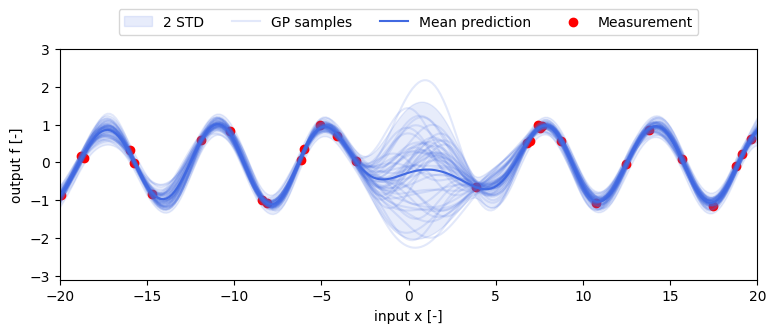

In [9]:

''' Define initial guess for the hyperparameters
    - lengthScaleSE
    - signalAmplitudeSE
    - noiseVariance 
    then transform to log space ''' 

initialLengthScaleSE = 2
initialsignalAmplitudeSE = 1
initialNoiseSTD = 0.01


''' Code for plotting: Do not change code below '''
''' Note, the optimiser assumes squared hyper-parameters, so we square the initial guess before transforming to log space '''
s0 = np.log([initialLengthScaleSE**2, initialsignalAmplitudeSE**2, initialNoiseSTD**2])

posDataOpt = np.hstack((np.random.uniform(-20, -3, 15).reshape(1, -1), np.random.uniform(3, 20, 15).reshape(1, -1)))
posPred = np.linspace(-20, 20, 250).reshape(1, -1)
yDataOpt = helper.generateData(posDataOpt, 'sin')

''' Optimize the hyperparameters using BFGS ''' 
result = opt.minimize(GP.expLogML, s0, jac=GP.expGradLogML, method='BFGS', args=(posDataOpt, yDataOpt))

''' Extract the optimized hyperparameters, transform back from log space ''' 
lengthScaleSquaredOpt = np.sqrt(np.exp(result.x[0]))
signalAmplitudeSEOpt = np.sqrt(np.exp(result.x[1]))
noiseSTDOpt = np.sqrt(np.exp(result.x[2]))

print("Optimised length scale:", lengthScaleSquaredOpt)
print("Optimised signal amplitude:", signalAmplitudeSEOpt)
print("Optimised noise standard deviation:", noiseSTDOpt)

plt.figure(figsize=(9,3), dpi=100)

f, cov = predictSE(posPred, posDataOpt, yDataOpt, lengthScaleSquaredOpt, signalAmplitudeSEOpt, noiseSTDOpt)
helper.makeGaussianProcessPredictionPlots(posDataOpt, yDataOpt, posPred, f, cov, 'none', noiseSTDOpt)



#### Making a magnetic field plot

Based on what you have learned before, you are able to make your very first magnetic field map using Gaussian processes. Note that the magnetic field you will map consists of the Earth's magnetic field and disturbances induced by ferro-magnetic materials in indoor environments. These two components can be modeled by a constant kernel and a squared exponential kernel respectively. The constant kernel is defined as

$$
\kappa_{\text{con}}(\mathbf{x}, \mathbf{x}') = \sigma^2_{\text{con}} 
$$


#### First load in the data
To start, first load in the data below
All variables you will use are numpy arrays, where
- `magnetometerMeasurements` $\in \mathbb{R}^{3 \times K}$ is a numpy array containing the magnetometer measurements
- `magnetometerPositions` $\in \mathbb{R}^{3 \times K}$ is a numpy array containing the true positions of the magnetometer

#### Warning
- Additionally you are provided with a dictionary modelParameters which is used in creating magnetic field maps. DO NOT CHANGE dictionary as this might break the assignment. To create the magnetic field map you DO NOT need this dictionary.
The data is similar to the two previous assignments. Although this time, you may assumes you have access to all the true magnetometer positions.

In [10]:
''' load in the data'''
(magnetometerMeasurements, 
 magnetometerPositions,
 modelParameters) = helper.initializeGaussianProcessAssignment(groupNumber % 29)

#### Task:

- Implement the functions `kernelSE`, `kernelMatrixSE`, `kernelConstant`, `kernelMatrixConstant` and `predictGPmagneticField`.
To begin, you may start with the hyper-parameters
- `lengthScale` = 1
- `signalAmplitudePeriod` = 1
- `noiseVariance` =  0.001
- `signalAmplitudeConstant` = 15


Manually tune the hyper-parameters so the magnetic field on the right is similar to the magnetic field on the left. They are approximately in the correct order of magnitude.

#### Note:
Try to make the measurements on the right subplots dissapear into the background.
The reference map on the left subplots is to guide you into what it should approximately look like. 


#### Analysis:

Elaborate on the physical interpretation of the hyper-parameters in the context of magnetic field mapping.


#### Hint:

From the reference magnetic field plot you can try to estimate a good intial guess for the length-scale and the signal amplitude.


## Answer

- lengthScaleSE represents the spatial extent to which local disturbances affect the magnetic field, since it controls how quickly the function can vary with position. A small value means disturbances are highly localized, changing rapidly with position. A large value makes disturbances affect larger areas, varying gradually over space. 
- signalAmplitudeSE controls the magnitude of the local magnetic disturbances caused by ferromagnetic materials. The larger the value, the larger the deviation from the Earth’s field. 
- noiseVariance represents the measurement noise in the magnetometer readings. A small value results in higher confidence in the measurements, so the measurements are followed very closely. This results in a more rough, jagged plot. A large value results in lower confidence in the measurements, so the measurements are trusted less. This results in a smoother magnetic field estimate that averages over sensor imprecision. 
- signalAmplitudeConstant represents the magnitude of the Earth's background magnetic field. Since we are operating in a relatively small environment (indoors), there is unlikely to be much variation in the Earth's field. Hence, we treat it as a fixed constant.

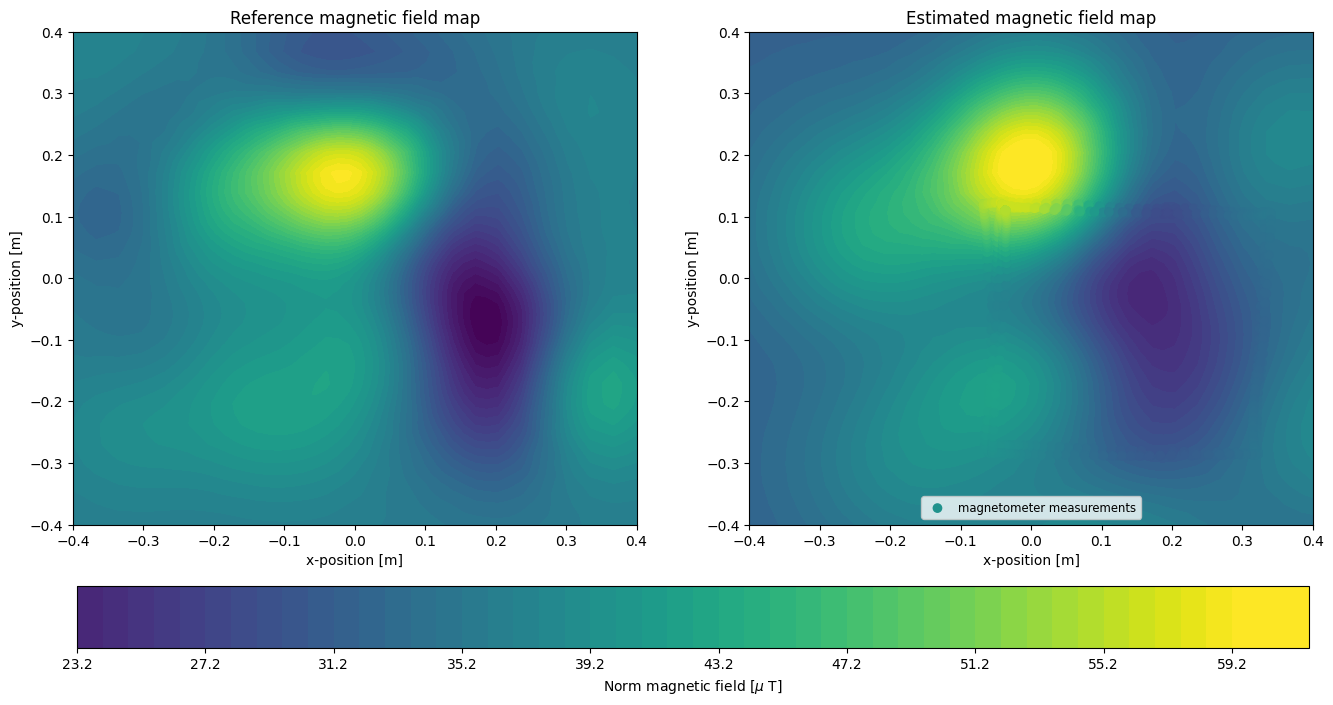

In [11]:


def kernelConstant(x1, x2, signalAmplitudeConstant):
    helper.testKernelValue(x1, x2)
    """
    Compute the Constant Kernel for a for a single input pair {x1, x2},
    
    Args:
        x1: Array of shape (numDim, 1)
        x2: Array of shape (numDim, 1)
        signalAmplitudeConstant: signal amplitude hyperparameter for the Constant Kernel.
    Returns:
        K: Scalar kernel value of shape (1, 1)
    """
    
    k = signalAmplitudeConstant
    
    return k

def kernelMatrixConstant(x1, x2, signalAmplitudeConstant):
    helper.testKernelMatrix(x1, x2)
    """
    Compute the Constant Kernel matrix for a set of input pairs {X1, X2}.

    Args:
        X1: Array of shape (numDim, numInputs1)
        X2: Array of shape (numDim, numInputs2)
        signalAmplitudeConstant: signal amplitude hyperparameter for the Constant Kernel.
    Returns:
         K: Kernel matrix of shape (numInputs1, numInputs2)
    """
    
    n = x1.shape[1]
    m = x2.shape[1]
    
    # K = np.zeros([n, m])

    # for i in range(n):
    #     for j in range(m):

    #         K[i][j] = kernelConstant(x1[:,i:i+1], x2[:,j:j+1], signalAmplitudeConstant)

    K = signalAmplitudeConstant * np.ones([n, m])
            
    return K

def predictGPmagneticField(xStar, xData, yData, lengthScaleSE, signalAmplitudeSE, noiseVariance, signalAmplitudeConstant):
    """ Compute the mean and covariance of the Gaussian Process Posterior defined by the sum of a Squared Exponential Kernel and a Constant Kernel

    Args:
        xStar: Array of shape (numDim, numTestInputs) containing the input locations
        xData: Array of shape (numDim, numTrainInputs) containing the training input locations
        yData: Array of shape (numTrainInputs, 1) containing the training output values
        lengthScaleSE: Length scale hyperparameter for the Squared Exponential Kernel.
        signalAmplitudeSE: signal amplitude hyperparameter for the Squared Exponential Kernel.
        noiseVariance: Noise variance hyperparameter for the Gaussian Process.
        signalAmplitudeConstant: signal amplitude hyperparameter for the Constant Kernel.
    Returns:
        mean: Array of shape (numTestInputs, 1) containing the mean of the Gaussian Process Posterior at the test input locations
        cov: Array of shape (numTestInputs, numTestInputs) containing the covariance of the Gaussian Process Posterior at the test input locations
    """ 
    
    numTrainInputs = xData.shape[1]
    
    K1 = kernelMatrixSE(xData, xData, lengthScaleSE, signalAmplitudeSE) + kernelMatrixConstant(xData, xData, signalAmplitudeConstant)
    K2 = kernelMatrixSE(xData, xStar, lengthScaleSE, signalAmplitudeSE) + kernelMatrixConstant(xData, xStar, signalAmplitudeConstant)
    K3 = kernelMatrixSE(xStar, xData, lengthScaleSE, signalAmplitudeSE) + kernelMatrixConstant(xStar, xData, signalAmplitudeConstant)
    K4 = kernelMatrixSE(xStar, xStar, lengthScaleSE, signalAmplitudeSE) + kernelMatrixConstant(xStar, xStar, signalAmplitudeConstant)

    L = np.linalg.cholesky(K1 + noiseVariance * np.eye(numTrainInputs), upper=False)

    L_inv = np.linalg.inv(L)
    a = L_inv.T @ (L_inv @ yData)
    v = L_inv @ K2

    mean = K3 @ a
    cov = K4 - v.T @ v
    
    return mean, cov



magnetometerNorm = np.linalg.norm(magnetometerMeasurements, ord=2, axis=0).reshape(-1, 1)

lengthScaleSE = 0.13 
signalAmplitudeSE = 0.85 
noiseVariance = 0.001
signalAmplitudeConstant = 0.6


''' Code for plotting: Do not change code below '''
posPred = linAlg.gridpointsHyperCube(25, 2, 3, np.array([[-0.4, 0.4], [-0.4, 0.4]]))
f, cov = predictGPmagneticField(posPred, magnetometerPositions, magnetometerNorm, lengthScaleSE, signalAmplitudeSE, noiseVariance, signalAmplitudeConstant)
helper.makeGaussianProcessMagneticFieldMapPlots(magnetometerPositions, posPred, f, cov, magnetometerNorm, modelParameters)



#### Feedback:
This is the first year we are teaching this course. Your feedback will be invaluable in improving it for the coming years. Please let us know in this markdown any comments, suggestions or errors you have encountered in the last three assignments.  
